In [2]:
# !pip install matplotlib

Cylindrical cavity resonator modes


##### This setup params

In [3]:
# My Cavity
# Radius 1.75 mm
a = 1.75  * 0.001
# length 34 mm
d = 34 * 0.001

# 1 mm = 0.001 m

##### Constants

In [4]:
import math
C = 299.792458 * 1e6 # m/s
mu_0 = 1.256 * 1e-6 # T* m/A, permeability of free space
e_0 = 8.85* 1e-12 # F/m, permittivity 

# Roots of Bessel function derivative (J'_n(x))
# roots TE Modes of circular waveguide
# p'_n,m 
pTE = {
    (0, 1): 3.8317, (0, 2): 7.0156, (0, 3): 10.1735,
    (1, 1): 1.8412, (1, 2): 5.3314, (1, 3): 8.5363,
    (2, 1): 3.0542, (2, 2): 6.7061, (2, 3): 9.9695,
    (3, 1): 4.2012, (3, 2): 8.0152, (3, 3): 11.3459
} 

# roots of Bessel function (J_n(x))
# roots of TM modes of circular waveguide
# p_n,m
pTM = {
    (0, 1): 2.4048, (0, 2): 5.5201, (0, 3): 8.6537,
    (1, 1): 3.8317, (1, 2): 7.0156, (1, 3): 10.1735,
    (2, 1): 5.1356, (2, 2): 8.4172, (2, 3): 11.6198,
    (3, 1): 6.3802, (3, 2): 9.7610, (3, 3): 13.0152
}


In [5]:

# Frequency of TE mode for cylindrical waveguide cavfity
    
def f_nml_TE(n, m, l, a, d, ur=1, er=1):
    """Resonant frequency of TE_nml mode for a cylindrical cavity."""
    # Retrieve the root from the pTE dictionary
    p_prime_nm = pTE[(n, m)]
    
    # Calculate the frequency using formula (6.53a)
    term1 = (p_prime_nm / a)**2
    term2 = (l * math.pi / d)**2
    
    multiplier = C / (2 * math.pi * math.sqrt(ur * er))
    return multiplier * math.sqrt(term1 + term2)

def f_nml_TM(n, m, l, a, d, ur=1, er=1):
    """Resonant frequency of TM_nml mode for a cylindrical cavity."""
    # Retrieve the root from the pTM dictionary
    p_nm = pTM[(n, m)]
    
    # Calculate the frequency using formula (6.53b)
    term1 = (p_nm / a)**2
    term2 = (l * math.pi / d)**2
    
    multiplier = C / (2 * math.pi * math.sqrt(ur * er))
    return multiplier * math.sqrt(term1 + term2)

# for vaccum, setting ur = er = 1



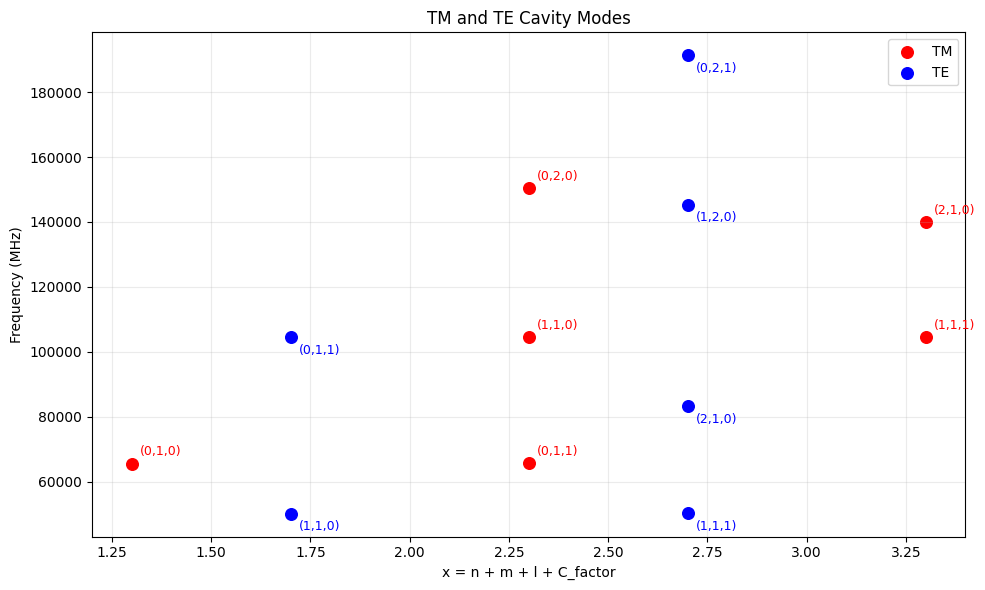

In [ ]:
import matplotlib.pyplot as plt

# First few TM and TE modes to visualize
tm_modes = [
    (0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1),
    (0, 2, 0), (2, 1, 0)
],
te_modes = [
    (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 0),
    (1, 2, 0), (0, 2, 1)
],

# Custom x-offset factors
c_factor_tm = 0.3
c_factor_te = -0.3

x_tm, y_tm, labels_tm = [], [], []
x_te, y_te, labels_te = [], [], []

for n, m, l in tm_modes:
    x_tm.append(n + m + l + c_factor_tm)
    y_tm.append(f_nml_TM(n, m, l, a, d) / 1e9)  # Hz -> GHz
    labels_tm.append(f"({n},{m},{l})")

for n, m, l in te_modes:
    x_te.append(n + m + l + c_factor_te)
    y_te.append(f_nml_TE(n, m, l, a, d) / 1e9)  # Hz -> GHz
    labels_te.append(f"({n},{m},{l})")

plt.figure(figsize=(10, 6))
plt.scatter(x_tm, y_tm, color="red", s=70, label="TM")
plt.scatter(x_te, y_te, color="blue", s=70, label="TE")

# Label each point with (n,m,l)
for x, y, txt in zip(x_tm, y_tm, labels_tm):
    plt.annotate(txt, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9, color="red")

for x, y, txt in zip(x_te, y_te, labels_te):
    plt.annotate(txt, (x, y), textcoords="offset points", xytext=(6, -12), fontsize=9, color="blue")

plt.xlabel("x = n + m + l + C_factor")
plt.ylabel("Frequency (GHz)")
plt.title("TM and TE Cavity Modes")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()